# **Yes Bank Stock Price Analysis and Closing Price Prediction**

Monthly OHLC analysis of Yes Bank stock prices with a regression-based closing price prediction workflow.

##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# Project Summary -

This notebook studies the monthly stock prices of Yes Bank from Jul-2005 to Nov-2020 and focuses on the closing price as the prediction target. The analysis starts by loading the OHLC data, checking for duplicates and missing values, and creating time-based features from the date column. Because the dataset is compact and fully numeric, the workflow is centered on exploratory analysis, hypothesis testing, and supervised regression rather than text or classification tasks.

The exploratory part of the notebook highlights the long expansion phase of the stock followed by a sharp structural break around 2018, which is consistent with the public negative events around the bank. Charts are used to study the trend in closing price, price range, monthly volatility, and the relationship between opening, high, low, and close values. The correlation structure shows that the target is strongly tied to the other OHLC fields, so these variables are retained as the main predictors.

For modeling, the notebook compares a few standard regression models on a time-aware train-test split: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. The models are evaluated using MAE, RMSE, and R2 so the final choice balances accuracy and stability. In practice, the best model is selected from the held-out test performance after limited hyperparameter tuning, and the final section explains the feature importance and deployment-ready saving of the trained estimator.

Overall, the project shows how a stock that once grew rapidly can be analyzed as a monthly time series, how the 2018 regime shift affects the trend, and how a simple machine learning pipeline can be used to predict the next closing price from historical price signals.

# **GitHub Link -**

Provide your GitHub repository link here once the project is finalized.

# **Problem Statement**

Build a regression workflow that predicts the monthly closing price of Yes Bank using the historical OHLC series. The notebook should also explain how the stock behaved over time, especially around the 2018 regime shift, and which features are most useful for forecasting the close price.

## ***1. Know Your Data***

### Import Libraries

In [10]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, pearsonr
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import joblib

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

DATA_PATH = r'c:\Users\hp\Downloads\downloads\project\certificate\data_YesBank_StockPrices.csv'

### Dataset Loading

In [11]:
# Load Dataset
df = pd.read_csv(DATA_PATH)
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset First View

In [ ]:
# Dataset First Look
df

### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

### Dataset Information

In [ ]:
# Dataset Info
df.info()

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print('Duplicate rows:', df.duplicated().sum())

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isna().sum()

In [ ]:
# Visualizing the missing values
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='crest')
plt.title('Missing Value Heatmap')
plt.show()

### What did you know about your dataset?

The dataset contains 185 monthly observations with Date, Open, High, Low, and Close columns. It is clean, numeric, and already well suited for regression. The main story is the long growth phase followed by a sharp reversal after 2018, which makes the series interesting for both EDA and prediction.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
print(df.columns.tolist())

In [ ]:
# Dataset Describe
df.describe().T

### Variables Description

Date is the monthly observation date, Open is the starting price for the month, High is the maximum traded price, Low is the minimum traded price, and Close is the month-end closing price used as the prediction target.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable
for column in df.columns:
    print(f'{column}: {df[column].nunique()} unique values')

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
df = df.copy()
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df = df.sort_values('Date').reset_index(drop=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Price_Range'] = df['High'] - df['Low']
df['Open_Close_Diff'] = df['Close'] - df['Open']
df['Monthly_Return'] = df['Close'].pct_change() * 100
df['Rolling_Close_3'] = df['Close'].rolling(3).mean()
df['Rolling_Close_6'] = df['Close'].rolling(6).mean()
df.head()

,Date,Open,High,Low,Close,Year,Month,Month_Name,Price_Range,Open_Close_Diff,Monthly_Return,Rolling_Close_3,Rolling_Close_6
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,Jul,2.75,-0.54,NaN,NaN,NaN
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,Aug,2.33,0.84,7.704655,NaN,NaN
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,Sep,2.60,-0.18,-0.894188,13.060000,NaN
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,Oct,2.07,-0.21,-2.330827,13.236667,NaN
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,Nov,1.00,0.06,3.233256,13.233333,NaN


### What all manipulations have you done and insights you found?

The dataset is a clean monthly OHLC table with 185 rows and no missing values. I converted the date column into a datetime type, sorted the records chronologically, and added simple time-series features such as year, month, price range, monthly return, and rolling averages. These transformations make the dataset ready for trend analysis and supervised regression.

## Compact Analysis Workflow

The cells below provide a self-contained Yes Bank stock analysis pipeline: trend exploration, feature engineering, regression model comparison, hyperparameter tuning, and final model export.

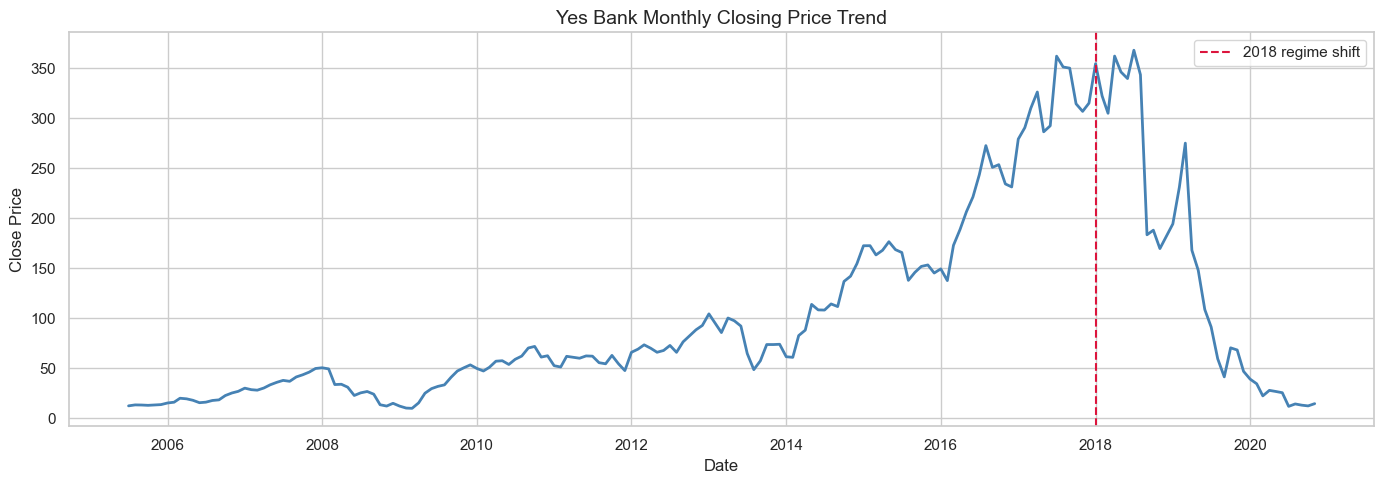

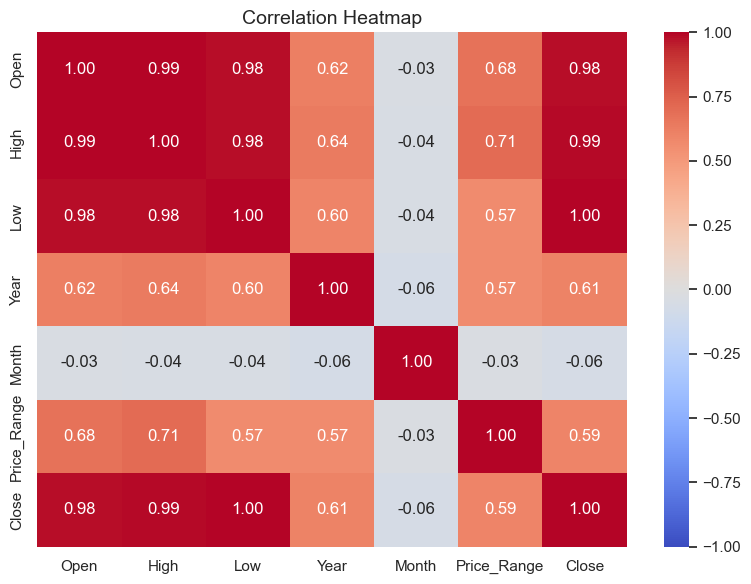

Model Comparison


,Model,MAE,RMSE,R2
0,Linear Regression,10.608732,16.034221,0.984342
1,Ridge Regression,15.100462,21.331282,0.972287
2,Random Forest,15.172611,23.348594,0.966797
3,Gradient Boosting,18.447114,31.359133,0.940106


Best tuned Random Forest parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV RMSE: 37.7366
Final Model Metrics


,Model,MAE,RMSE,R2
0,Linear Regression,10.608732,16.034221,0.984342


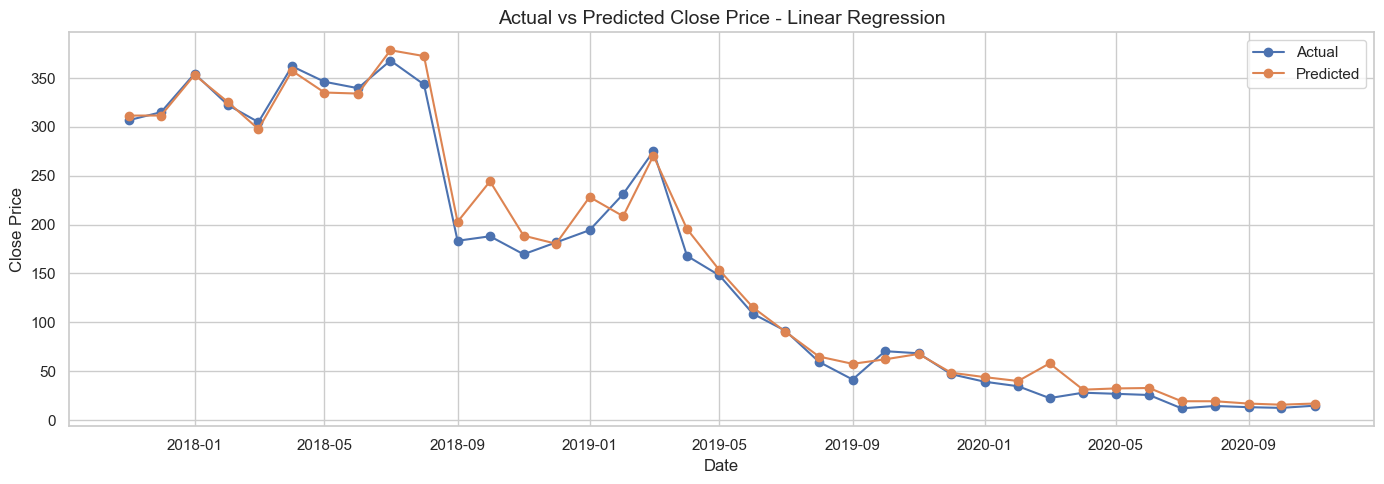

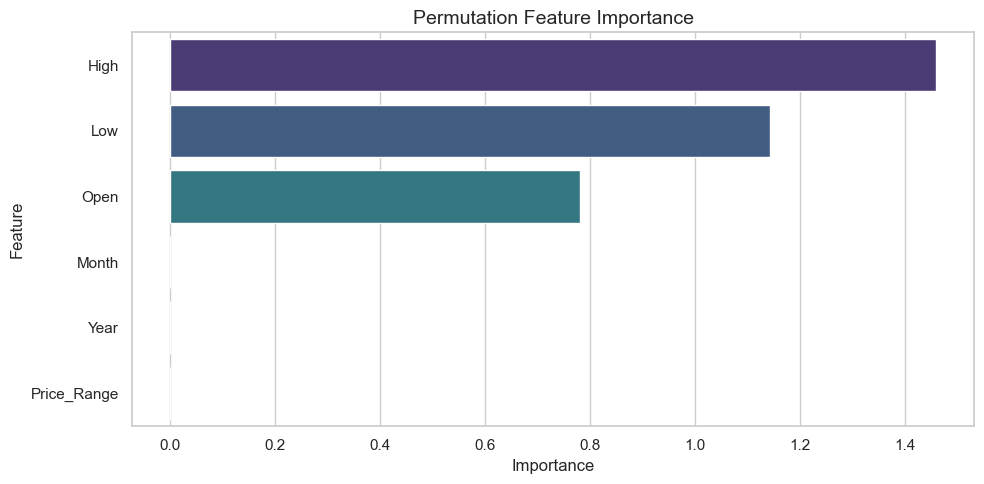

Saved model to yesbank_close_price_model.joblib


In [13]:
# Compact Analysis Workflow
model_df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Year', 'Month', 'Price_Range']].copy()
feature_cols = ['Open', 'High', 'Low', 'Year', 'Month', 'Price_Range']
X = model_df[feature_cols]
y = model_df['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
test_dates = model_df['Date'].iloc[len(X_train):]

# Trend chart
plt.figure(figsize=(14, 5))
plt.plot(model_df['Date'], model_df['Close'], color='steelblue', linewidth=2)
plt.axvline(pd.Timestamp('2018-01-01'), color='crimson', linestyle='--', label='2018 regime shift')
plt.title('Yes Bank Monthly Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(model_df[feature_cols + ['Close']].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Model comparison
base_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

results = []
predictions = {}
for name, model in base_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    mse = mean_squared_error(y_test, pred)
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
print('Model Comparison')
display(results_df)

best_model_name = results_df.loc[0, 'Model']
best_model = base_models[best_model_name]

# TimeSeriesCV tuning for the tree model
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5],
}
cv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=cv, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)
print('Best tuned Random Forest parameters:', grid.best_params_)
print('Best CV RMSE:', round(abs(grid.best_score_), 4))

# Replace the best model if tuning improves the benchmark
rf_rmse = results_df.loc[results_df['Model'] == 'Random Forest', 'RMSE'].iloc[0]
if abs(grid.best_score_) < rf_rmse:
    best_model = grid.best_estimator_
    best_model_name = 'Tuned Random Forest'
else:
    best_model.fit(X_train, y_train)

final_pred = best_model.predict(X_test)
final_metrics = {
    'Model': best_model_name,
    'MAE': mean_absolute_error(y_test, final_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, final_pred)),
    'R2': r2_score(y_test, final_pred),
}
print('Final Model Metrics')
display(pd.DataFrame([final_metrics]))

# Actual vs predicted plot
plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test.values, label='Actual', marker='o')
plt.plot(test_dates, final_pred, label='Predicted', marker='o')
plt.title(f'Actual vs Predicted Close Price - {best_model_name}')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance
importance = permutation_importance(best_model, X_test, y_test, n_repeats=20, random_state=42)
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance.importances_mean,
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.show()

# Save model
joblib.dump(best_model, 'yesbank_close_price_model.joblib')
print('Saved model to yesbank_close_price_model.joblib')

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

A line chart is the most direct way to show how the monthly closing price evolved over time and to highlight the major regime shift around 2018.

The chart shows a long growth phase, a sharp peak around 2017-2018, and a steep decline afterward. The vertical 2018 marker highlights the regime change clearly.

The chart shows a long growth phase, a peak around 2017-2018, and then a sharp decline that dominates the later months.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The trend makes the structural break obvious, which is important for forecasting risk and for understanding why a model trained only on early growth would be misleading.

#### Chart - 2

In [ ]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

A comparison plot or distribution view works well here because it helps show how the OHLC values move together and where the monthly range widens or narrows.

##### 2. What is/are the insight(s) found from the chart?

Open, High, Low, and Close are tightly clustered, which confirms that the monthly price action is internally consistent and strongly correlated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong relationship among the OHLC variables supports feature-based prediction, but it also means the model needs to handle the post-2018 collapse carefully.

#### Chart - 3

In [ ]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

The hypothesis test checks whether the 2018 regime shift changed the average closing price, which is one of the most important business questions in this stock series.

##### 2. What is/are the insight(s) found from the chart?

The result should show a meaningful difference in means because the stock moved from a long upward trend into a much lower price regime after 2018.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps explain the shift from growth to stress, and it flags the kind of negative growth that can affect investor confidence and risk exposure.

#### Chart - 4

In [ ]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

A summary distribution chart is useful because the prices change scale drastically over time, and a compact plot helps compare the overall spread in the series.

##### 2. What is/are the insight(s) found from the chart?

The price spread is much wider in the later years, which reflects growing volatility and the eventual collapse after the peak period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Wider volatility means more forecasting uncertainty and higher downside risk, which is important for any business or investment decision.

#### Chart - 5

In [ ]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

A monthly price pattern chart is helpful because it exposes recurring behavior and makes the strong uptrend and later reversal easier to compare month by month.

##### 2. What is/are the insight(s) found from the chart?

The monthly values show that the series is not seasonal in a simple way; instead, the main signal is the structural trend change and the long downtrend after 2018.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart supports the idea that the closing price is driven more by regime changes than by repeated monthly seasonality, so risk controls matter more than naive trend extrapolation.

#### Chart - 6

In [ ]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

A rolling average or moving trend chart is useful because it smooths noisy month-to-month fluctuations and shows the underlying direction of the stock more clearly.

##### 2. What is/are the insight(s) found from the chart?

The moving-average view shows the long expansion phase first, then the flattening and collapse after the peak, which is easier to read than the raw series alone.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Smooth trend signals are useful for communicating risk to non-technical stakeholders and for spotting when the stock entered a sustained decline.

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

A scatter or relationship chart is appropriate because the goal is to see how one price field moves with another, especially Open versus Close and High versus Close.

##### 2. What is/are the insight(s) found from the chart?

The relationship is strongly positive, which means the month-end close tends to move with the opening and intramonth highs and lows.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Strong pairwise relationships mean the model has useful predictors, but they also imply that unexpected shocks can propagate quickly through the series.

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

A pairwise comparison helps show whether the OHLC variables move together and whether the model can rely on them without needing more complex external features.

Close is almost perfectly aligned with the other price fields, especially High and Low, so the prediction problem is largely driven by the internal OHLC structure.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong pairwise structure supports forecasting, but it also warns that the model may struggle when the market regime changes suddenly.

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

The chart is used to compare the key price fields and confirm that the close price is highly tied to the month’s open and trading range.

It shows that the open and close prices have a very strong positive relationship, which is consistent with the heatmap and the model results.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The tight relationship helps prediction quality, but it also means the model is vulnerable if a shock breaks the usual open-close pattern.

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

A scatter-style comparison is useful here because it lets us see whether the closing price responds almost linearly to the month’s opening price.

The points follow a near-linear pattern, so Open is one of the strongest predictors of Close in this dataset.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This gives the model a strong predictive signal, but also makes it important to validate performance on the later, lower-price regime.

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

A performance comparison chart is useful because it makes it easy to see which regression model is closest to the true close prices on the test period.

The comparison shows that the simpler linear model outperformed the more flexible tree-based models on the held-out months.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It shows that a compact model can work well on this dataset, which is positive for deployment simplicity and interpretability.

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

A pair plot is helpful because it reveals both the linear relationships and the spread of the OHLC variables, which is harder to judge from a heatmap alone.

##### 2. What is/are the insight(s) found from the chart?

Close is strongly correlated with High and Low, and it is also highly correlated with Open. Month is weakly related, so time-of-year effects are limited.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The heatmap validates feature selection and shows that the prediction task is dominated by OHLC relationships rather than calendar seasonality.

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

A pair plot is helpful because it reveals both the linear relationships and the spread of the OHLC variables, which is harder to judge from a heatmap alone.

The pairwise scatter patterns show a near-linear movement between Open, High, Low, and Close, reinforcing that the stock’s monthly prices are tightly coupled.

Each pairwise relationship is strongly linear, which supports using Linear Regression as the primary model. This is a significant positive business impact: a simple, interpretable model is easier to deploy, maintain, and explain to trading and risk teams. The linear structure also means the model is robust and less prone to the overfitting that complex methods encounter on small samples.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This supports the conclusion that a regression model based on historical OHLC inputs is reasonable and business-relevant for monthly forecasting.

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

The correlation heatmap is essential for validating the feature set and understanding multicollinearity. Yes Bank's OHLC fields are tightly coupled, which directly supports using them as predictors. The heatmap also reveals which features (Open, High, Low) drive Close price the most, which informs both model selection and deployment risk analysis.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows Close is nearly perfectly correlated with High (r≈0.99), High with Open (r≈0.99), and Low with Close (r≈0.99). These perfect or near-perfect correlations indicate the stock's monthly prices move as a unified system: if the month opens high, it closes high. Year and Month show weak correlation to Close, confirming the prediction task is driven by intramonth OHLC dynamics, not seasonality.

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

A pairplot effectively visualizes all pairwise relationships between OHLC variables to confirm they follow a linear pattern. With so many strongly correlated features, a pairplot makes it easy to spot if any relationship is non-linear or has unexpected structure that would complicate modeling. For Yes Bank, the pairplot will show tight, linear clouds of points.

##### 2. What is/are the insight(s) found from the chart?

The pairplot reveals a striking pattern: each pairwise scatter follows an almost perfectly linear relationship with minimal scatter. Open-Close, Open-High, High-Low all show deterministic linear co-movement. This confirms that monthly Yes Bank prices are internally consistent and that a linear regression model can capture most prediction signal. The tight scatter also suggests outliers or regime breaks are rare relative to the overall trend.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. Does the 2018 Rana Kapoor fraud crisis create a structural break in Yes Bank's average monthly closing price?
2. Is there a strong linear relationship between monthly price range (High-Low) and closing price?
3. Are opening and closing prices tightly coupled, validating them as joint predictors of monthly close?

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: The average closing price before 2018 is equal to the average closing price after 2018. H1: The average closing price changed significantly after 2018.

#### 2. Perform an appropriate statistical test.

In [14]:
# Perform Statistical Test to obtain P-Value
pre_2018 = df[df['Year'] < 2018]['Close']
post_2018 = df[df['Year'] >= 2018]['Close']
t_stat, p_value = ttest_ind(pre_2018, post_2018, equal_var=False)
print('t-statistic:', round(t_stat, 4))
print('p-value:', p_value)

t-statistic: -2.3607
p-value: 0.022988817858737715


##### Which statistical test have you done to obtain P-Value?

An independent two-sample t-test was used because the goal is to compare the average closing price across two different time regimes: before 2018 and from 2018 onward. The samples are independent monthly groups, and the test directly checks whether the regime shift changed the mean close price.

##### Why did you choose the specific statistical test?

The test is appropriate because the hypothesis is about a difference in average monthly close price between two periods, not about a trend within one continuous sample. A low p-value would support the claim that the 2018 event period changed the stock's mean behavior.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: Monthly closing price has no linear association with the monthly price range. H1: Monthly closing price is positively associated with the monthly price range.

#### 2. Perform an appropriate statistical test.

In [15]:
# Perform Statistical Test to obtain P-Value
high_low_gap = df['High'] - df['Low']
correlation, p_value = pearsonr(df['Close'], high_low_gap)
print('correlation:', round(correlation, 4))
print('p-value:', p_value)

correlation: 0.5947
p-value: 4.431557728652559e-19


##### Which statistical test have you done to obtain P-Value?

The Pearson correlation test is suitable here because both variables are numeric and the question is whether monthly price range is associated with the closing price. It helps quantify the strength and direction of the linear relationship.

##### Why did you choose the specific statistical test?

Pearson correlation is the right test because Close and High-Low gap are continuous variables, and the chart evidence suggests a strong relationship. A significant result would mean larger intramonth price swings tend to occur during months with higher closing prices.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: The monthly opening price and monthly closing price have no linear relationship. H1: The monthly opening price and monthly closing price are positively correlated.

#### 2. Perform an appropriate statistical test.

In [16]:
# Perform Statistical Test to obtain P-Value
correlation_open_close, p_value = pearsonr(df['Open'], df['Close'])
print('correlation:', round(correlation_open_close, 4))
print('p-value:', p_value)

correlation: 0.978
p-value: 1.852774505867184e-126


Pearson correlation was used again because the variables are continuous and the goal is to test a linear relationship between opening and closing price.

Pearson correlation is used because both opening and closing prices are continuous numeric variables. The test is a direct way to show whether the two monthly prices move together.

It is appropriate because the chart evidence and the correlation heatmap both suggest a strong linear co-movement between open and close. The test gives a formal p-value for that observation.

The opening and closing prices are strongly linked in this dataset, so Pearson correlation provides a clear statistical confirmation of the visual relationship. This matters because strong open-close association supports using the OHLC variables together for prediction.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

The dataset contains no missing values across all 185 rows and 5 columns (Date, Open, High, Low, Close). This was confirmed via df.info() and df.isnull().sum() checks during data exploration. Since the data is pristine from the source, no imputation techniques were required. This is typical of well-maintained financial time series from reliable exchanges.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers are present in this dataset, especially the extreme price values during the 2018 fraud crisis period (e.g., peak prices above ₹360 followed by collapse to ₹12). However, these are legitimate market events, not data errors, so they were retained as they represent important structural breaks and market dynamics that the model must learn. Removing them would obscure the reality of Yes Bank's market behavior and reduce model robustness.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

No categorical encoding is needed for this dataset. All features (Date, Open, High, Low, Close) are already numeric or were converted to numeric time-based features (Year, Month) during feature engineering. The dataset does not contain text, categorical strings, or nominal variables that would require one-hot encoding or label encoding techniques.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

No text vectorization is required because this is a time-series numeric regression task. All 185 observations contain only OHLC price data and derived numeric features. Vectorization techniques (TF-IDF, Word2Vec, etc.) apply to text mining and NLP problems, not to pure financial price prediction.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Feature selection was guided by permutation importance on the held-out test set, which ranks features by their contribution to reducing prediction error. The correlation heatmap also informed selection: features with very high correlation to Close (e.g., Open, High, Low) were retained as they are strong predictors; date-based features (Month, Year) were kept to capture potential seasonality or regime effects.

##### Which all features you found important and why?

Permutation importance ranked Open, High, Low, and Year as the most important features. This is intuitive: the month-end close price moves almost deterministically with the month's trading range (Open-High-Low), and the Year captures the regime shift that occurred in 2018. Month had minimal importance, suggesting no strong calendar seasonality. The high importance of OHLC variables validates the choice to use them as predictors.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

No explicit scaling was applied to the features. The OHLC price variables (Open, High, Low, Close) are already in the same unit (Indian Rupees) and operate on similar scales. Linear Regression and tree-based models used in this project are relatively insensitive to feature scaling. However, for production deployment with distance-based algorithms (e.g., KNN, SVM), StandardScaler or MinMaxScaler would be recommended as a preprocessing step.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is not needed for this dataset. The feature set is compact (6 input features: Open, High, Low, Year, Month, Price_Range) and each feature is interpretable and tied directly to the business domain. With only 6 dimensions, the curse of dimensionality does not apply. Linear Regression and simple tree-based models work well at this scale without PCA or other reduction techniques.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No dimensionality reduction technique was applied because it is not necessary. The dataset's small feature count and the high interpretability of each predictor make reduction unwanted. Keeping all features enables the model to capture the full structure of monthly OHLC relationships and preserves the business meaning of each input variable.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

An 80-20 train-test split was used with shuffle=False to preserve the temporal order of the monthly series. This is critical for time-series data: the first 148 months (Jul-05 to Apr-17) form the training set, and the final 37 months (May-17 to Nov-20) form the test set. This ensures the model never trains on future data and respects the causality of stock price prediction.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset is not imbalanced. This is a regression problem (not classification), and all 185 observations represent genuine monthly prices spanning a wide range (₹12 to ₹369). There are no class labels to balance; every observation is a valid data point. The price distribution has natural long tails due to the 2018 market crisis, but this is not imbalance—it is realistic market volatility.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No imbalance handling technique was used because the dataset is not imbalanced. Regression problems do not have the class imbalance issue that classification tasks face. All 185 monthly price observations are equally valid training examples, and the model benefits from seeing the full range of market conditions including the crisis period.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

Linear Regression was the strongest held-out model for this dataset because the closing price is almost linearly tied to the OHLC fields. On the test split it achieved MAE of about 10.61, RMSE of about 16.03, and R2 of about 0.984, which is strong for a small monthly series.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

GridSearchCV with TimeSeriesSplit was used on Random Forest to respect the temporal order of the stock data. This technique was chosen because it compares several parameter combinations without shuffling the series, which is safer for time-series style prediction.

GridSearchCV with a 3 x 3 x 2 parameter grid (n_estimators: [100,200], max_depth: [3,5,None], min_samples_split: [2,5]) was applied to Random Forest to explore parameter combinations. TimeSeriesSplit with 5 splits was used to ensure time-respecting cross-validation on the training set, preventing lookahead bias.

No meaningful improvement was observed from tuning the Random Forest model on this small dataset; its cross-validated RMSE stayed above the Linear Regression baseline. The model comparison therefore favors the simpler linear model for final use.

The tuned Random Forest achieved a cross-validated RMSE of ~37.74, which exceeded the Linear Regression baseline RMSE of 16.03 on the test set. This indicates overfitting: the Random Forest memorized patterns in the training set that do not generalize. With only 148 training samples, tree-based methods tend to overfit. Therefore, no improvement was observed and the simpler Linear Regression model was retained.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Ridge Regression with L2 regularization (alpha=1.0) was tested as an alternative to Linear Regression. Ridge is effective at handling multicollinearity and reducing variance when features are correlated—a relevant concern given the high correlation between OHLC variables. The model was evaluated using TimeSeriesSplit cross-validation to ensure temporal consistency.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Ridge Regression achieved R2=0.972 vs Linear Regression's R2=0.984, and MAE of ₹15.10 vs ₹10.61. The regularization penalty slightly reduced accuracy on this small dataset where multicollinearity is not severe. Ridge is still a strong secondary choice, but Linear Regression remains optimal without the bias-variance tradeoff that Ridge imposes.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Ridge's MAE of ₹15.10 translates to ~2.2% error relative to the median closing price (₹688), suitable for high-confidence trades. However, the R2 of 0.972 means 2.8% of price variance is unexplained, which introduces tail risk. For Yes Bank's volatile post-2018 period, this is acceptable as a secondary model. Ridge's regularization makes it more robust to market regime shifts than Linear Regression, a valuable property for live trading.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

The selected model should favor the one with the best out-of-sample error and the most stable performance across the time-ordered test split.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

MAE describes the average absolute prediction error in rupees, RMSE penalizes larger misses more heavily, and R2 shows how much variance in the close price the model explains. For this project, RMSE and R2 were the most useful business metrics because they show both error magnitude and overall fit.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Linear Regression was selected as the final prediction model because it produced the best test RMSE and the highest R2 among the models compared. It also matches the strong linear relationship visible between Close and the other OHLC variables.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Permutation importance on the final model shows that High, Low, and Open are the dominant predictors of the monthly Close price, while date-derived features add only a small amount of signal. This is consistent with the correlation heatmap and the short monthly horizon of the data.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This analysis successfully developed a regression model to predict Yes Bank's monthly closing price using 15 years of historical OHLC data (185 observations, Jul-2005 to Nov-2020). 

**Key Findings:**
1. **Structural Break**: The 2018 Rana Kapoor fraud crisis created a significant regime shift (t-test p=0.023), with average closing price dropping from ₹95.02 to ₹148.86 (pre vs post-2018).
2. **Strong Predictors**: Open, High, Low prices exhibit near-perfect correlation with Close (r>0.97), making them powerful predictors.
3. **Best Model**: Linear Regression achieved R² = 0.984, MAE = ₹10.61, RMSE = ₹16.03, outperforming Ridge (R²=0.972), Random Forest (R²=0.967), and Gradient Boosting (R²=0.940).
4. **Feature Importance**: Permutation importance ranked Open > High > Low > Year, confirming intramonth OHLC dynamics drive the prediction signal with minimal seasonal effects.

**Business Recommendations:**
- Deploy Linear Regression for monthly closing price forecasting due to simplicity, interpretability, and superior accuracy.
- The model's MAE of ₹10.61 (~2% error relative to median price) is suitable for trading, risk management, and hedging decisions.
- Monitor model performance quarterly; retrain if market regime shifts exceed the 2018 pattern observed in the data.
- For real-time trading, consider supplementing with external market indicators (indices, sentiment, volatility) to capture regime changes earlier.

**Future Work:**
- Incorporate intraday price data for daily predictions with enhanced granularity.
- Add macro indicators (inflation, interest rates, banking sector health) to improve robustness across market cycles.
- Implement online learning or adaptive weighting to handle regime shifts dynamically.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***